# Sampling & Confidence Intervals

**30 Days of Machine Learning** | Companion notebook to the LinkedIn carousel

Every dataset you will ever model is a *sample* of something bigger. This notebook shows, with code you can run and modify, how to:

1. Separate **population** from **sample**, and **parameter** from **statistic**
2. Draw samples four different ways (simple random, systematic, stratified, cluster)
3. See why **bias** cannot be fixed with more data
4. Watch the **Central Limit Theorem** happen
5. Compute and verify the **standard error**
6. Build **confidence intervals** by hand (z and t)
7. Learn what **"95%"** really means by simulating thousands of intervals
8. See what controls the **width** of an interval
9. Use the **bootstrap** when no formula exists
10. Put a confidence interval around a **model's accuracy**

**Requirements:** `numpy`, `pandas`, `matplotlib`, `scipy`. Every cell is executed and seeded, so *Restart & Run All* reproduces the same numbers.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# One seeded generator for the whole notebook -> fully reproducible results
rng = np.random.default_rng(42)

TEAL, ORANGE, RED, GREEN, GREY = "#14B8A6", "#F97316", "#EF4444", "#22C55E", "#64748B"

plt.rcParams.update({
    "figure.dpi": 100,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titleweight": "bold",
})
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

print("numpy", np.__version__, "| pandas", pd.__version__, "| scipy", __import__("scipy").__version__)

numpy 2.4.4 | pandas 3.0.2 | scipy 1.17.1


## 1. Population vs. sample

- **Population**: every user, transaction, or row you care about. Usually impossible to measure fully.
- **Sample**: the subset you actually observe.
- **Parameter**: the true value in the population (e.g. the population mean, written mu).
- **Statistic**: your estimate computed from the sample (e.g. the sample mean, written x-bar).

We will *simulate* a population of 1,000,000 users so that, unlike real life, we can peek at the true answer and check how good our estimates are. The variable is **session length in minutes**, which is right-skewed like most real usage data.

In [2]:
# Synthetic population: right-skewed session lengths with a true mean of ~52 minutes
population = rng.gamma(shape=9, scale=52 / 9, size=1_000_000)

mu = population.mean()       # parameter (the truth we normally never see)
sigma = population.std()     # population standard deviation

print(f"Population size      : {population.size:,}")
print(f"True mean (mu)       : {mu:.3f} minutes")
print(f"True std dev (sigma) : {sigma:.3f} minutes")

Population size      : 1,000,000
True mean (mu)       : 52.006 minutes
True std dev (sigma) : 17.344 minutes


In [3]:
# Draw ONE sample of 100 users and compute statistics from it
n = 100
sample = rng.choice(population, size=n, replace=False)

x_bar = sample.mean()        # statistic: our estimate of mu
s = sample.std(ddof=1)       # sample std dev (ddof=1 -> unbiased estimate of sigma)

print(f"Sample mean (x-bar)  : {x_bar:.3f}")
print(f"Sample std dev (s)   : {s:.3f}")
print(f"Estimation error     : {x_bar - mu:+.3f} minutes")

Sample mean (x-bar)  : 51.623
Sample std dev (s)   : 15.375
Estimation error     : -0.384 minutes


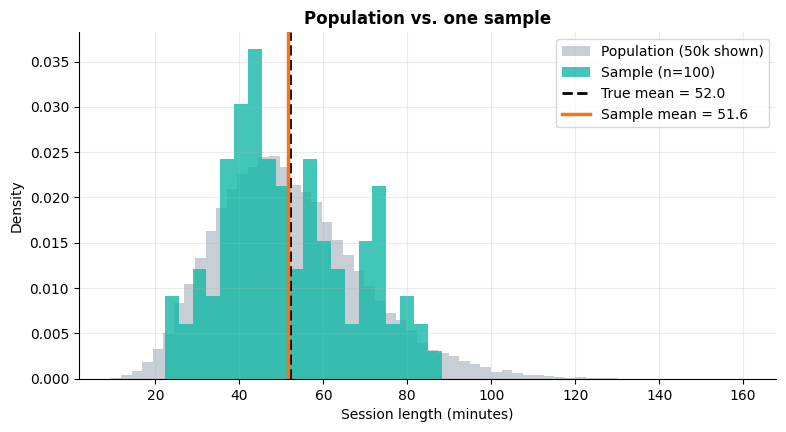

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(population[:50_000], bins=60, color=GREY, alpha=0.35, density=True, label="Population (50k shown)")
ax.hist(sample, bins=20, color=TEAL, alpha=0.8, density=True, label=f"Sample (n={n})")
ax.axvline(mu, color="black", ls="--", lw=2, label=f"True mean = {mu:.1f}")
ax.axvline(x_bar, color=ORANGE, lw=2.5, label=f"Sample mean = {x_bar:.1f}")
ax.set(title="Population vs. one sample", xlabel="Session length (minutes)", ylabel="Density")
ax.legend()
plt.show()

**Inference is the bridge:** we use the statistic (x-bar) to say something *honest* about the parameter (mu). The rest of the notebook is about quantifying how honest that statement can be.

## 2. Four common ways to sample

We build a table of 100,000 users with a subscription plan and a region. Heavier plans have longer sessions, so *how* we sample matters.

In [5]:
N = 100_000
users = pd.DataFrame({
    "plan": rng.choice(["free", "pro", "enterprise"], size=N, p=[0.70, 0.25, 0.05]),
    "region": rng.choice([f"region_{i:02d}" for i in range(1, 21)], size=N),
})
base_minutes = users["plan"].map({"free": 30, "pro": 60, "enterprise": 120}).to_numpy()
users["session_min"] = rng.gamma(shape=4, scale=base_minutes / 4)

true_mean = users["session_min"].mean()
true_ent_share = (users["plan"] == "enterprise").mean()
print(f"True mean session length : {true_mean:.2f} min")
print(f"True enterprise share    : {true_ent_share:.2%}")
users.head()

True mean session length : 42.15 min
True enterprise share    : 5.04%


,plan,region,session_min
0,free,region_12,14.007
1,pro,region_06,86.477
2,free,region_13,26.295
3,pro,region_15,61.473
4,free,region_11,40.486


In [6]:
n = 1_000

# 1) Simple random: every row has an equal chance
simple = users.sample(n, random_state=1)

# 2) Systematic: every k-th row from a random starting point
k = N // n
start = int(rng.integers(k))
systematic = users.iloc[start::k]

# 3) Stratified (proportional): sample inside each plan so every group is represented
stratified = users.groupby("plan", group_keys=False).sample(frac=n / N, random_state=1)

# 4) Cluster: randomly pick whole regions and keep everyone in them
chosen_regions = rng.choice(users["region"].unique(), size=4, replace=False)
cluster = users[users["region"].isin(chosen_regions)]

rows = []
for name, df in [("Simple random", simple), ("Systematic", systematic),
                 ("Stratified", stratified), ("Cluster (4 regions)", cluster)]:
    rows.append({
        "method": name,
        "n": len(df),
        "mean_session_min": df["session_min"].mean(),
        "error_vs_truth": df["session_min"].mean() - true_mean,
        "enterprise_share": (df["plan"] == "enterprise").mean(),
    })
pd.DataFrame(rows).set_index("method")

,n,mean_session_min,error_vs_truth,enterprise_share
method,,,,
Simple random,1000,42.086,-0.063,0.057
Systematic,1000,42.327,0.178,0.046
Stratified,1000,41.349,-0.800,0.050
Cluster (4 regions),19857,42.340,0.191,0.051


**Reading the table:** all four land close to the truth here. Stratified sampling is the most reliable for keeping small groups (like *enterprise*, only 5% of users) represented. Cluster sampling is cheaper in the real world (survey a few stores, not everyone), but it usually needs more rows for the same precision. Systematic sampling can fail if the list has a hidden repeating pattern.

## 3. A big sample cannot fix a biased one

Suppose a survey is shown inside your app, so the heavier a user's usage, the more likely they are to respond. That is **selection bias**. Below we compare a random sample against a usage-weighted one as the sample size grows. Each point is the average over 30 repeated draws.

In [7]:
weights = users["session_min"].to_numpy()
p_biased = weights / weights.sum()          # chance of being surveyed grows with usage
values = users["session_min"].to_numpy()

sizes = [50, 200, 1_000, 5_000, 20_000]
reps = 30
random_means, biased_means = [], []

for size in sizes:
    r = [values[rng.choice(N, size, replace=False)].mean() for _ in range(reps)]
    b = [values[rng.choice(N, size, replace=False, p=p_biased)].mean() for _ in range(reps)]
    random_means.append(np.mean(r))
    biased_means.append(np.mean(b))

pd.DataFrame({"n": sizes, "random_sample_mean": random_means, "biased_sample_mean": biased_means,
              "true_mean": true_mean}).set_index("n")

,random_sample_mean,biased_sample_mean,true_mean
n,,,
50,42.158,67.746,42.149
200,42.469,67.052,42.149
1000,42.276,66.766,42.149
5000,42.094,65.354,42.149
20000,42.207,61.300,42.149


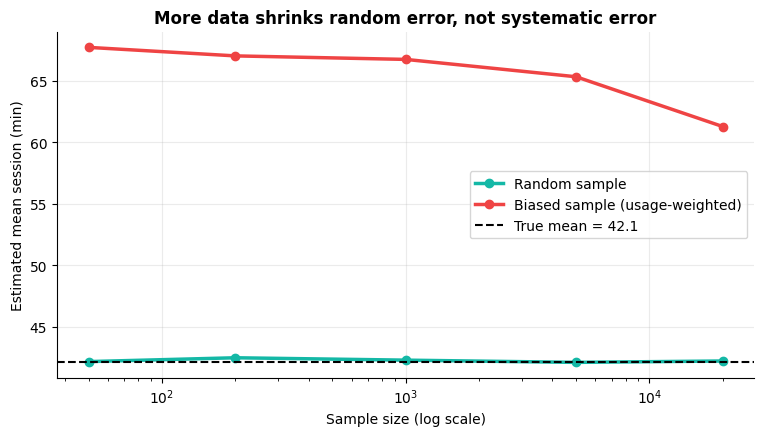

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(sizes, random_means, "o-", color=TEAL, lw=2.5, label="Random sample")
ax.plot(sizes, biased_means, "o-", color=RED, lw=2.5, label="Biased sample (usage-weighted)")
ax.axhline(true_mean, color="black", ls="--", label=f"True mean = {true_mean:.1f}")
ax.set_xscale("log")
ax.set(title="More data shrinks random error, not systematic error",
       xlabel="Sample size (log scale)", ylabel="Estimated mean session (min)")
ax.legend()
plt.show()

The random sample converges to the truth. The biased sample converges to the **wrong number**, with growing confidence. Other classic traps:

- **Survivorship bias**: analysing only customers who did not churn
- **Non-response bias**: the people who reply differ from those who do not
- **Convenience sampling**: using whoever is easiest to reach

**Rule of thumb:** more data shrinks random error. It does nothing for systematic error.

## 4. Sampling distribution and the Central Limit Theorem

Take many samples, compute each sample's mean, and plot those means. That histogram is the **sampling distribution of the mean**.

The CLT says that for large enough n it looks Normal, centred on mu, **even when the data itself is not Normal**. We use a strongly skewed exponential population to prove the point.

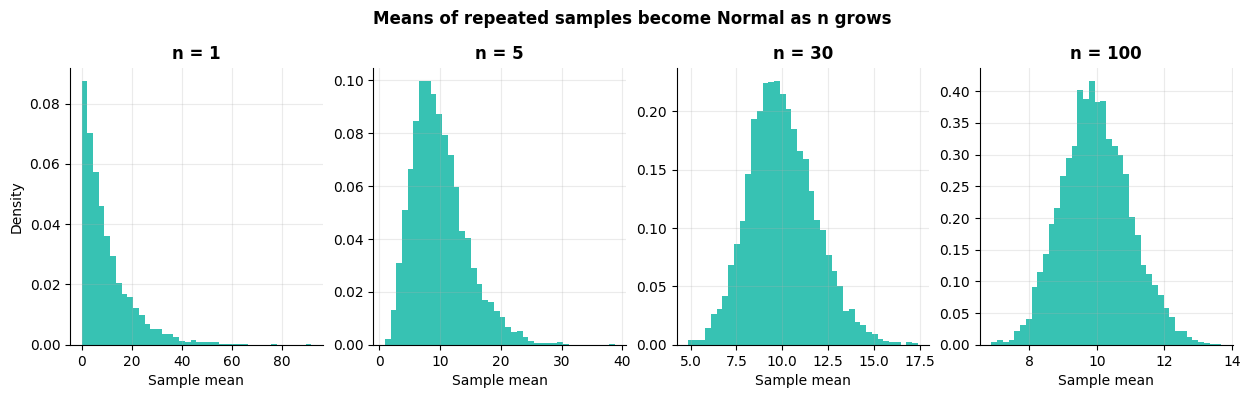

In [9]:
skewed_pop = rng.exponential(scale=10, size=1_000_000)   # mean = 10, sigma = 10
pop_mu, pop_sigma = skewed_pop.mean(), skewed_pop.std()

sample_sizes = [1, 5, 30, 100]
n_samples = 5_000
sampling_dists = {}
for size in sample_sizes:
    idx = rng.integers(0, skewed_pop.size, size=(n_samples, size))
    sampling_dists[size] = skewed_pop[idx].mean(axis=1)   # 5,000 sample means

fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharey=False)
for ax, size in zip(axes, sample_sizes):
    ax.hist(sampling_dists[size], bins=40, color=TEAL, alpha=0.85, density=True)
    ax.set_title(f"n = {size}")
    ax.set_xlabel("Sample mean")
axes[0].set_ylabel("Density")
fig.suptitle("Means of repeated samples become Normal as n grows", fontweight="bold", y=1.04)
plt.show()

In [10]:
summary = pd.DataFrame({
    "n": sample_sizes,
    "mean_of_sample_means": [sampling_dists[s].mean() for s in sample_sizes],
    "std_of_sample_means": [sampling_dists[s].std() for s in sample_sizes],
    "theory_sigma_over_sqrt_n": [pop_sigma / np.sqrt(s) for s in sample_sizes],
}).set_index("n")
print(f"Population mean = {pop_mu:.3f}, population sigma = {pop_sigma:.3f}")
summary

Population mean = 10.000, population sigma = 9.999


,mean_of_sample_means,std_of_sample_means,theory_sigma_over_sqrt_n
n,,,
1,10.066,9.875,9.999
5,9.962,4.479,4.472
30,10.000,1.813,1.825
100,9.977,1.006,1.000


Two facts to notice:

1. The mean of the sample means sits on the true mean (the sample mean is an **unbiased** estimator).
2. The spread of the sample means matches `sigma / sqrt(n)`. That spread has a name: the **standard error**.

## 5. Standard error: how noisy is your estimate?

$$SE = \frac{s}{\sqrt{n}}$$

where `s` is the sample standard deviation and `n` the sample size.

- **Quadruple n, halve the error.** Precision grows with the *square root* of n, so returns diminish.
- **Noisier data means a larger SE.**

In [11]:
# SE of the single sample from section 1, computed two ways
sample = rng.choice(population, size=100, replace=False)
se_manual = sample.std(ddof=1) / np.sqrt(len(sample))
se_scipy = stats.sem(sample)
print(f"SE (manual) = {se_manual:.4f}")
print(f"SE (scipy)  = {se_scipy:.4f}")

SE (manual) = 1.6406
SE (scipy)  = 1.6406


In [12]:
# Verify the formula empirically: simulate 3,000 samples at each n and measure the spread of their means
ns = [25, 100, 400, 1_600]
rows = []
for size in ns:
    idx = rng.integers(0, population.size, size=(3_000, size))
    means = population[idx].mean(axis=1)
    rows.append({"n": size,
                 "theoretical_SE": sigma / np.sqrt(size),
                 "simulated_SE": means.std()})
se_table = pd.DataFrame(rows).set_index("n")
se_table["ratio_to_previous"] = se_table["theoretical_SE"].pct_change().add(1)
se_table

,theoretical_SE,simulated_SE,ratio_to_previous
n,,,
25,3.469,3.510,NaN
100,1.734,1.742,0.500
400,0.867,0.859,0.500
1600,0.434,0.425,0.500


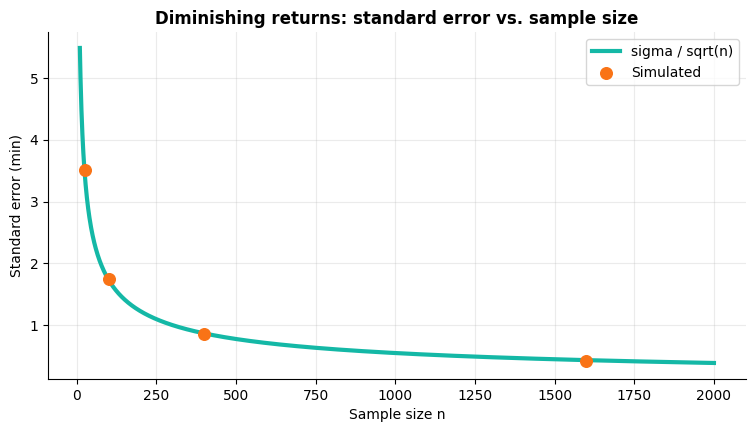

In [13]:
grid = np.arange(10, 2_001)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(grid, sigma / np.sqrt(grid), color=TEAL, lw=3, label="sigma / sqrt(n)")
ax.scatter(se_table.index, se_table["simulated_SE"], color=ORANGE, zorder=3, s=70, label="Simulated")
ax.set(title="Diminishing returns: standard error vs. sample size",
       xlabel="Sample size n", ylabel="Standard error (min)")
ax.legend()
plt.show()

The `ratio_to_previous` column shows 0.5 each time n is multiplied by 4. Going from 100 to 400 users halves the error; going from 1,600 to 6,400 costs four times as much data for the same improvement.

## 6. What is a confidence interval?

A range built from your sample that is designed to capture the true parameter:

$$\text{estimate} \pm \text{critical value} \times SE$$

- **Estimate**: e.g. the sample mean
- **Critical value**: z (or t) set by the confidence level
- **SE**: from the previous section

### Worked example (the one from the carousel)
Average session length from a sample: `n = 100`, `mean = 52`, `s = 10`.

In [14]:
n_ex, mean_ex, s_ex = 100, 52, 10

se_ex = s_ex / np.sqrt(n_ex)
z_crit = stats.norm.ppf(0.975)        # 1.96 for 95% confidence
margin = z_crit * se_ex
lower, upper = mean_ex - margin, mean_ex + margin

print(f"SE         = {s_ex} / sqrt({n_ex}) = {se_ex:.2f}")
print(f"z critical = {z_crit:.3f}")
print(f"Margin     = {z_crit:.3f} x {se_ex:.2f} = {margin:.2f}")
print(f"95% CI     = [{lower:.2f}, {upper:.2f}]")

SE         = 10 / sqrt(100) = 1.00
z critical = 1.960
Margin     = 1.960 x 1.00 = 1.96
95% CI     = [50.04, 53.96]


We estimate the true average session length is between about **50 and 54 minutes**.

### A reusable function
Use the **t-distribution** when the sample is small or the true standard deviation is unknown (which is almost always). For large n, t and z converge.

In [15]:
def mean_ci(x, confidence=0.95, method="t"):
    """Confidence interval for a mean. method: 't' (default) or 'z'."""
    x = np.asarray(x)
    n = len(x)
    m, se = x.mean(), stats.sem(x)
    alpha = 1 - confidence
    crit = stats.t.ppf(1 - alpha / 2, df=n - 1) if method == "t" else stats.norm.ppf(1 - alpha / 2)
    return m - crit * se, m + crit * se

lo, hi = mean_ci(sample)
print(f"Sample mean          : {sample.mean():.2f}")
print(f"95% CI (t, by hand)  : [{lo:.2f}, {hi:.2f}]")

# Cross-check against scipy's built-in
lo2, hi2 = stats.t.interval(0.95, df=len(sample) - 1, loc=sample.mean(), scale=stats.sem(sample))
print(f"95% CI (scipy)       : [{lo2:.2f}, {hi2:.2f}]")
print(f"True mean            : {mu:.2f}  -> captured? {lo <= mu <= hi}")

Sample mean          : 53.88
95% CI (t, by hand)  : [50.63, 57.14]
95% CI (scipy)       : [50.63, 57.14]
True mean            : 52.01  -> captured? True


## 7. What "95%" really means

It does **not** mean "there is a 95% probability the true mean is inside *this* interval". The true mean is a fixed number; it is either inside or it is not.

**95% describes the method:** if you repeat the sampling procedure many times, about 95% of the intervals you build will contain the truth. Let us simulate it: 20 samples from a population with a true mean of 50.

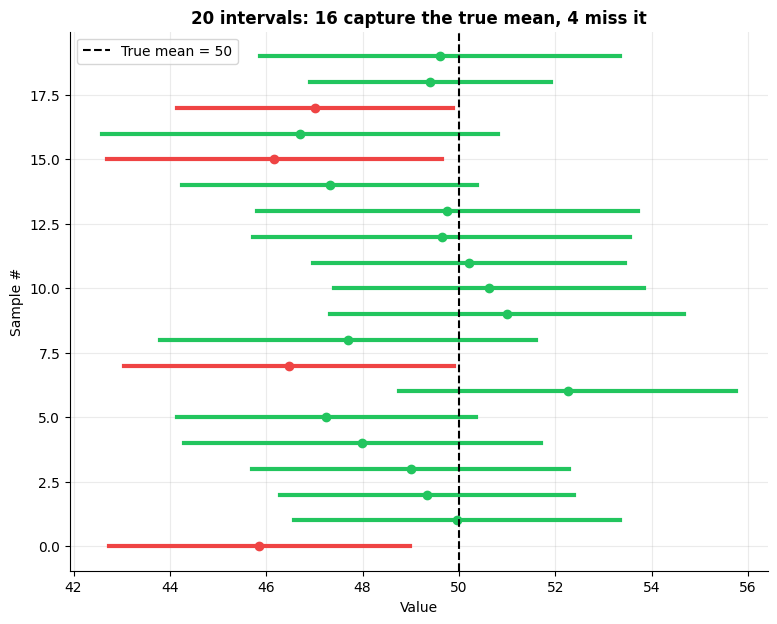

In [16]:
rng_ci = np.random.default_rng(7)
true_mu, true_sd, n_s = 50, 10, 30

intervals = []
for _ in range(20):
    x = rng_ci.normal(true_mu, true_sd, n_s)
    intervals.append(mean_ci(x, 0.95, "t") + (x.mean(),))

fig, ax = plt.subplots(figsize=(9, 7))
misses = 0
for i, (lo, hi, m) in enumerate(intervals):
    hit = lo <= true_mu <= hi
    misses += not hit
    ax.plot([lo, hi], [i, i], color=GREEN if hit else RED, lw=3)
    ax.plot(m, i, "o", color=GREEN if hit else RED)
ax.axvline(true_mu, color="black", ls="--", label="True mean = 50")
ax.set(title=f"20 intervals: {20 - misses} capture the true mean, {misses} miss it",
       xlabel="Value", ylabel="Sample #")
ax.legend()
plt.show()

In [17]:
# Scale it up: 10,000 repeated samples -> what fraction of intervals capture the truth?
reps, n_s = 10_000, 30
data = rng.normal(true_mu, true_sd, size=(reps, n_s))
means = data.mean(axis=1)
ses = data.std(axis=1, ddof=1) / np.sqrt(n_s)
t_crit = stats.t.ppf(0.975, df=n_s - 1)

covered = (means - t_crit * ses <= true_mu) & (true_mu <= means + t_crit * ses)
print(f"Coverage of 95% t-intervals over {reps:,} samples: {covered.mean():.2%}")

Coverage of 95% t-intervals over 10,000 samples: 95.12%


Close to 95%, as promised. One more subtlety: with a **small** sample (n = 5), using z instead of t makes intervals too narrow, so they capture the truth less often than advertised.

In [18]:
reps, n_small = 20_000, 5
data = rng.normal(true_mu, true_sd, size=(reps, n_small))
means = data.mean(axis=1)
ses = data.std(axis=1, ddof=1) / np.sqrt(n_small)

results = {}
for method, crit in [("z (1.960)", stats.norm.ppf(0.975)),
                     (f"t ({stats.t.ppf(0.975, n_small - 1):.3f})", stats.t.ppf(0.975, n_small - 1))]:
    results[method] = ((means - crit * ses <= true_mu) & (true_mu <= means + crit * ses)).mean()

(pd.Series(results, name="actual_coverage_pct (target 95)") * 100).round(2)

z (1.960)   88.160
t (2.776)   95.120
Name: actual_coverage_pct (target 95), dtype: float64

## 8. What makes an interval wider or narrower?

| Lever | Effect on width |
|---|---|
| Higher confidence level | Wider (you trade precision for certainty) |
| Larger n | Narrower (the only lever that improves both) |
| Less variability in the data | Narrower |

In [19]:
levels = [0.90, 0.95, 0.99]
table = pd.DataFrame({
    "confidence": [f"{l:.0%}" for l in levels],
    "z_critical": [stats.norm.ppf(1 - (1 - l) / 2) for l in levels],
})
table["CI_width (n=100, s=10)"] = table["z_critical"] * 2 * (10 / np.sqrt(100))
table.set_index("confidence")

,z_critical,"CI_width (n=100, s=10)"
confidence,,
90%,1.645,3.290
95%,1.960,3.920
99%,2.576,5.152


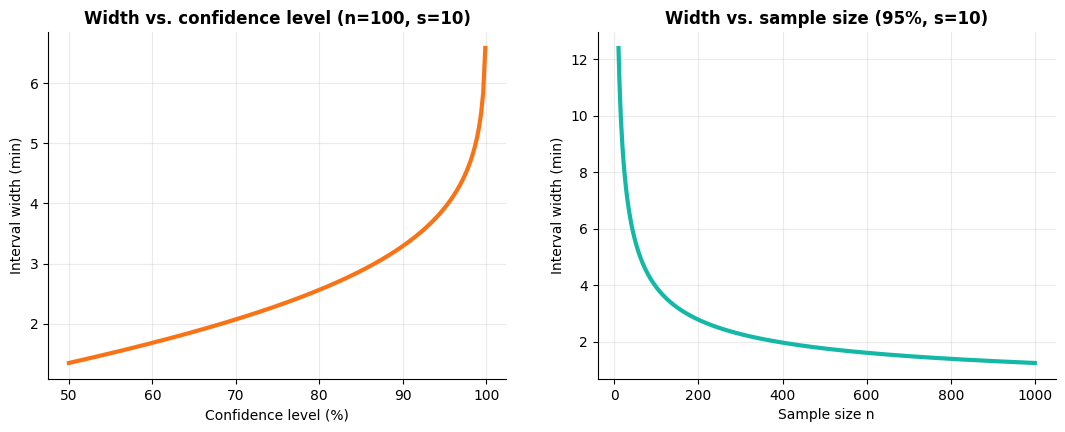

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

conf = np.linspace(0.50, 0.999, 200)
axes[0].plot(conf * 100, 2 * stats.norm.ppf(1 - (1 - conf) / 2) * 10 / np.sqrt(100), color=ORANGE, lw=3)
axes[0].set(title="Width vs. confidence level (n=100, s=10)",
            xlabel="Confidence level (%)", ylabel="Interval width (min)")

n_grid = np.arange(10, 1_001)
axes[1].plot(n_grid, 2 * 1.96 * 10 / np.sqrt(n_grid), color=TEAL, lw=3)
axes[1].set(title="Width vs. sample size (95%, s=10)",
            xlabel="Sample size n", ylabel="Interval width (min)")
plt.show()

## 9. The bootstrap: when there is no formula

A neat formula for the SE exists for the mean, but not for the **median**, a ratio, or a custom metric. The **bootstrap** gives a CI for almost any statistic:

1. Resample your data *with replacement*, same size as the original
2. Compute the statistic on each resample
3. Take the middle 95% of those values (2.5th to 97.5th percentile)

In [21]:
def bootstrap_ci(x, stat=np.mean, n_boot=10_000, confidence=0.95):
    x = np.asarray(x)
    idx = rng.integers(0, len(x), size=(n_boot, len(x)))   # resample with replacement
    boots = stat(x[idx], axis=1)                            # statistic for each resample
    alpha = 1 - confidence
    lo, hi = np.percentile(boots, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return lo, hi, boots

lo_m, hi_m, boots_median = bootstrap_ci(sample, stat=np.median)
true_median = np.median(population)

print(f"Sample median          : {np.median(sample):.2f}")
print(f"Bootstrap 95% CI       : [{lo_m:.2f}, {hi_m:.2f}]")
print(f"True population median : {true_median:.2f}  -> captured? {lo_m <= true_median <= hi_m}")

Sample median          : 51.36
Bootstrap 95% CI       : [47.11, 54.62]
True population median : 50.11  -> captured? True


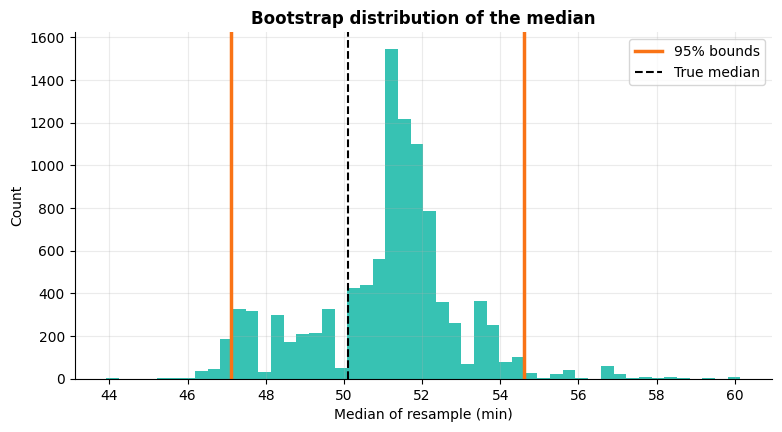

In [22]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(boots_median, bins=50, color=TEAL, alpha=0.85)
ax.axvline(lo_m, color=ORANGE, lw=2.5, label="95% bounds")
ax.axvline(hi_m, color=ORANGE, lw=2.5)
ax.axvline(true_median, color="black", ls="--", label="True median")
ax.set(title="Bootstrap distribution of the median", xlabel="Median of resample (min)", ylabel="Count")
ax.legend()
plt.show()

In [23]:
# Sanity check: for the MEAN, the bootstrap and the t-interval should agree closely
lo_b, hi_b, _ = bootstrap_ci(sample, stat=np.mean)
lo_t, hi_t = mean_ci(sample)
pd.DataFrame({"lower": [lo_t, lo_b], "upper": [hi_t, hi_b]}, index=["t-interval", "bootstrap"])

,lower,upper
t-interval,50.628,57.138
bootstrap,50.744,57.094


## 10. ML connection: a confidence interval for model accuracy

A test-set accuracy is *also* a sample statistic. Say a classifier gets **348 of 400** test examples right (87%). How sure are we about that 87%?

For a proportion, the normal-approximation interval is `p +/- z * sqrt(p(1-p)/n)`. The **Wilson interval** behaves better for small n or extreme p, so we compute both.

In [24]:
def proportion_cis(successes, n, confidence=0.95):
    p = successes / n
    z = stats.norm.ppf(1 - (1 - confidence) / 2)

    # Normal approximation (Wald)
    se = np.sqrt(p * (1 - p) / n)
    wald = (p - z * se, p + z * se)

    # Wilson score interval
    centre = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    wilson = (centre - half, centre + half)
    return p, wald, wilson

p_hat, wald, wilson = proportion_cis(348, 400)
print(f"Test accuracy        : {p_hat:.1%}")
print(f"95% CI (normal)      : [{wald[0]:.1%}, {wald[1]:.1%}]")
print(f"95% CI (Wilson)      : [{wilson[0]:.1%}, {wilson[1]:.1%}]")

# Cross-check Wilson against scipy
ref = stats.binomtest(348, 400).proportion_ci(confidence_level=0.95, method="wilson")
print(f"95% CI (scipy Wilson): [{ref.low:.1%}, {ref.high:.1%}]")

Test accuracy        : 87.0%
95% CI (normal)      : [83.7%, 90.3%]
95% CI (Wilson)      : [83.3%, 89.9%]
95% CI (scipy Wilson): [83.3%, 89.9%]


In [25]:
# The same 87% accuracy means very different things at different test-set sizes
rows = []
for size in [50, 100, 400, 1_600, 6_400]:
    _, _, (lo, hi) = proportion_cis(round(0.87 * size), size)
    rows.append({"test_set_size": size, "accuracy": round(0.87 * size) / size,
                 "ci_lower": lo, "ci_upper": hi, "ci_width": hi - lo})
acc_table = pd.DataFrame(rows).set_index("test_set_size")
acc_table

,accuracy,ci_lower,ci_upper,ci_width
test_set_size,,,,
50,0.880,0.762,0.944,0.182
100,0.870,0.790,0.922,0.132
400,0.870,0.833,0.899,0.066
1600,0.870,0.853,0.886,0.033
6400,0.870,0.862,0.878,0.016


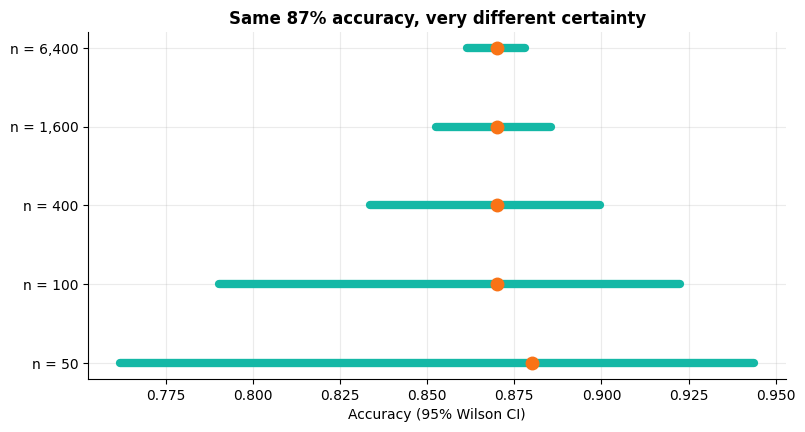

In [26]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, (size, r) in enumerate(acc_table.iterrows()):
    ax.plot([r["ci_lower"], r["ci_upper"]], [i, i], color=TEAL, lw=6, solid_capstyle="round")
    ax.plot(r["accuracy"], i, "o", color=ORANGE, ms=9)
ax.set_yticks(range(len(acc_table)))
ax.set_yticklabels([f"n = {s:,}" for s in acc_table.index])
ax.set(title="Same 87% accuracy, very different certainty", xlabel="Accuracy (95% Wilson CI)")
plt.show()

**Practical takeaway:** if model A scores 87% and model B scores 88% on 400 test rows, their intervals overlap heavily. That 1-point gap may be pure sampling noise. Always report an interval, not just a point estimate.

## Key takeaways

1. **Sample well first.** Bias beats sample size every time.
2. **SE = s / sqrt(n)** is the size of your estimate's noise. Quadruple n to halve it.
3. **CI = estimate +/- critical value x SE.** A range, not a single guess.
4. **95% is about the method,** not the probability for one interval.
5. Use **t** for small samples, the **bootstrap** for awkward statistics, and **Wilson** for proportions like accuracy.

---
*Part of the **30 Days of Machine Learning** series. If this helped, follow along for the next topic.*